# Méthodes de gradient proximal — ISTA & FISTA
### Résoudre un problème convexe quand la fonction n'est pas dérivable

**Projet d'optimisation convexe — Sujet B**

> Ce notebook est le fil conducteur du projet. Il part du *pourquoi* (quel problème, pourquoi les méthodes du cours ne suffisent pas) et construit pas à pas le chemin jusqu'aux algorithmes **ISTA** et **FISTA**. Chaque membre du groupe prolonge ensuite une section (théorie, preuves, état de l'art, application audio).

---
*Sommaire*
1. Le cadre : de l'optimisation convexe du cours à notre problème
2. Un problème concret : retrouver un signal parcimonieux
3. Pourquoi les méthodes du cours échouent ici
4. L'idée clé : l'opérateur proximal
5. ISTA : l'algorithme de base
6. FISTA : la même idée, accélérée
7. La course de convergence
8. Ce que la suite du projet va construire


## 0. Mise en place

On importe les bibliothèques et on fixe un style graphique homogène pour toutes les figures du projet (palette sobre, typographie lisible). On définit aussi une graine aléatoire pour que les résultats soient **reproductibles**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler

# --- Style graphique commun au projet -------------------------------------
PALETTE = ["#2E5EAA", "#E07A3F", "#3C9D6E", "#9B5DE5", "#444444"]
plt.rcParams.update({
    "figure.figsize":      (8, 5),
    "figure.dpi":          120,
    "axes.prop_cycle":     cycler(color=PALETTE),
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.alpha":          0.25,
    "grid.linestyle":      "--",
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      11,
    "font.family":         "DejaVu Sans",
    "legend.frameon":      False,
})

RNG = np.random.default_rng(0)   # reproductibilite
print("Environnement pret.")

Environnement pret.


## 1. Du cours à notre problème

Le cours nous a appris qu'un **problème d'optimisation convexe** s'écrit

$$\min_{x \in A} \; f(x)$$

où la fonction objectif $f$ est **convexe** et l'ensemble admissible $A$ est **convexe**. Sa propriété fondamentale — la *propriété-or* — est que :

> pour une fonction convexe, **tout minimum local est un minimum global**.

Autrement dit : pas de piège, pas de "creux" sous-optimal, un seul sommet à atteindre.

Le cours a ensuite donné deux familles de méthodes de résolution :

| Cas | Méthode vue en cours | Hypothèse nécessaire |
|---|---|---|
| objectif **lisse** | descente de gradient, Newton | $f$ **dérivable** partout |
| objectif **linéaire** | simplex | $f$ et contraintes **linéaires** |

**La question de ce projet :** que se passe-t-il quand $f$ est convexe mais **ni lisse ni linéaire** ? C'est un cas extrêmement courant, et aucune des deux méthodes ci-dessus ne s'applique directement. C'est là qu'interviennent les **méthodes de gradient proximal**.

## 2. Un problème concret : retrouver un signal parcimonieux

Plaçons-nous dans une situation typique. On observe un vecteur de mesures $y \in \mathbb{R}^n$, relié à un vecteur inconnu $x \in \mathbb{R}^p$ par une matrice connue $A \in \mathbb{R}^{n \times p}$ :

$$y = A\,x + \text{bruit}.$$

Le point crucial : **il y a plus d'inconnues que de mesures** ($p > n$). Le système est *sous-déterminé* — il admet une infinité de solutions $x$ compatibles avec $y$. Sans information supplémentaire, le problème est mal posé.

L'information qu'on ajoute : on sait que le vrai signal est **parcimonieux** (*sparse*), c'est-à-dire qu'il n'a que **quelques coefficients non nuls**. C'est une hypothèse réaliste — beaucoup de signaux naturels (audio, images) ont une représentation creuse dans une bonne base.

Fabriquons un tel problème pour le manipuler.

In [4]:
# Dimensions : plus d'inconnues (p) que de mesures (n) -> systeme sous-determine
n, p, k = 100, 300, 10        # n mesures, p variables, k coefficients non nuls

# Matrice de mesure A (gaussienne, normalisee)
A = RNG.standard_normal((n, p)) / np.sqrt(n)

# Vrai signal parcimonieux : seulement k coefficients non nuls
x_true = np.zeros(p)
support = RNG.choice(p, k, replace=False)      # positions des coeffs non nuls
x_true[support] = RNG.standard_normal(k)       # valeurs

# Observation bruitee
y = A @ x_true + 0.01 * RNG.standard_normal(n)

print(f"x a {p} composantes, dont seulement {k} non nulles.")
print(f"On observe seulement {n} mesures.")
print(f"-> {p} inconnues pour {n} equations : infinite de solutions possibles.")

x a 300 composantes, dont seulement 10 non nulles.
On observe seulement 100 mesures.
-> 300 inconnues pour 100 equations : infinite de solutions possibles.


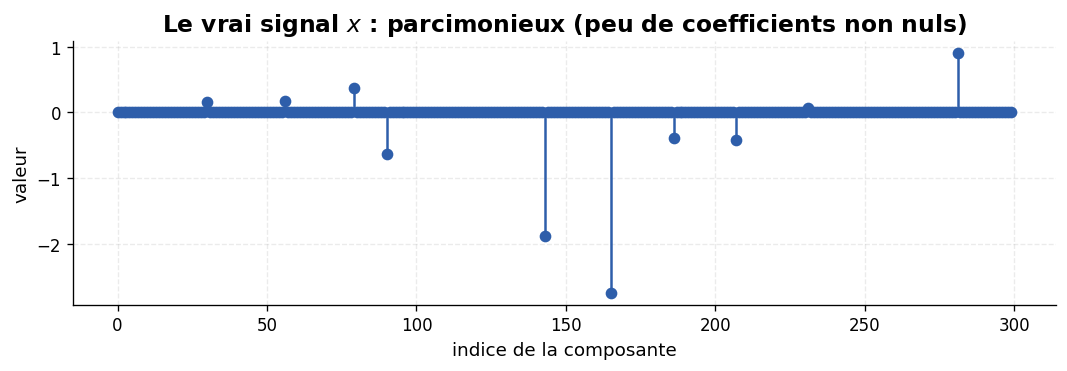

In [5]:
# Visualisons le vrai signal : un vecteur creux
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.stem(x_true, linefmt="-", markerfmt="o", basefmt=" ")
ax.set_title("Le vrai signal $x$ : parcimonieux (peu de coefficients non nuls)")
ax.set_xlabel("indice de la composante")
ax.set_ylabel("valeur")
plt.tight_layout()
plt.show()

Pour retrouver $x$, on minimise un objectif en **deux morceaux** :

$$\min_{x \in \mathbb{R}^p} \; F(x) = \underbrace{\tfrac{1}{2}\,\lVert A x - y \rVert_2^2}_{f(x)\ :\ \text{fidélité aux données}} \;+\; \lambda \underbrace{\lVert x \rVert_1}_{g(x)\ :\ \text{parcimonie}}$$

- Le premier terme $f(x)$ pousse $x$ à **expliquer les mesures** $y$. Il est quadratique, donc lisse et convexe.
- Le second terme $\lambda\lVert x\rVert_1 = \lambda\sum_i |x_i|$ **pénalise les coefficients non nuls** et force la solution à être creuse. Il est convexe, mais **non dérivable**.
- $\lambda > 0$ règle le compromis entre les deux.

Ce problème porte un nom : c'est le **LASSO**. Vérifions d'abord qu'il est bien **convexe**, pour rester dans le cadre du cours.

### 2.1 Le problème est-il convexe ?

On le justifie avec les règles du cours :

1. $f(x) = \tfrac12\lVert Ax - y\rVert_2^2$ est une fonction **quadratique** dont la matrice hessienne est $A^\top A$, qui est **semi-définie positive** (car $u^\top A^\top A\,u = \lVert Au\rVert^2 \ge 0$). Donc $f$ est convexe.
2. $g(x) = \lambda\lVert x\rVert_1$ est une **norme** (multipliée par $\lambda>0$), or toute norme est convexe.
3. **Une somme de fonctions convexes est convexe** (vu en TD). Donc $F = f + g$ est convexe.
4. L'ensemble admissible est $\mathbb{R}^p$ tout entier, qui est trivialement convexe.

$F$ est donc une fonction convexe sur un ensemble convexe : la **propriété-or** s'applique, il existe un minimum global et c'est lui qu'on cherche. ✓

## 3. Pourquoi les méthodes du cours échouent ici

Le terme $\lVert x\rVert_1$ contient des valeurs absolues $|x_i|$. Or la fonction $t \mapsto |t|$ présente un **coin en 0** : sa dérivée vaut $-1$ à gauche, $+1$ à droite, et **n'existe pas en 0**.

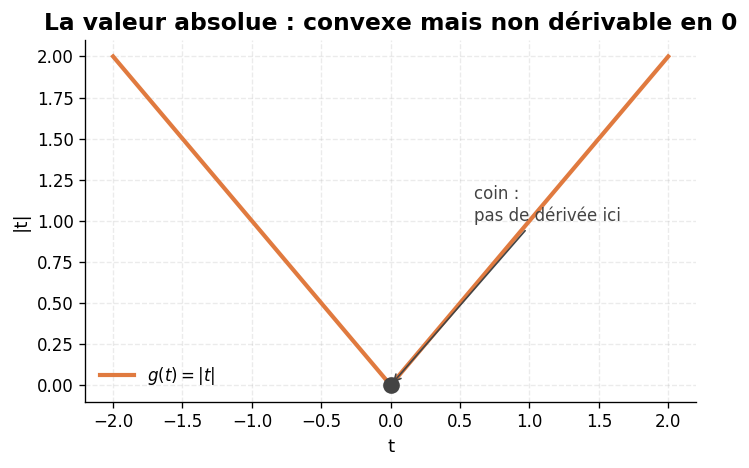

In [6]:
# Le point de blocage : la valeur absolue n'est pas derivable en 0
t = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, np.abs(t), color=PALETTE[1], lw=2.5, label="$g(t) = |t|$")
ax.plot(0, 0, "o", color=PALETTE[4], ms=9, zorder=5)
ax.annotate("coin :\npas de dérivée ici", xy=(0, 0), xytext=(0.6, 1.0),
            arrowprops=dict(arrowstyle="->", color=PALETTE[4]),
            fontsize=10, color=PALETTE[4])
ax.set_title("La valeur absolue : convexe mais non dérivable en 0")
ax.set_xlabel("t"); ax.set_ylabel("|t|"); ax.legend()
plt.tight_layout()
plt.show()

**Conséquence directe :**

- La **descente de gradient** a besoin du gradient $\nabla F$. Mais $\nabla F$ n'existe pas là où des composantes de $x$ valent 0 — et c'est précisément là que se trouve la solution (creuse !). Inutilisable.
- La **méthode de Newton** exige en plus la dérivée seconde. Encore pire.
- Le **simplex** ne traite que les objectifs **linéaires** ; le nôtre est quadratique. Hors sujet.

Il nous faut donc un outil capable de gérer ce "coin". Cet outil, c'est l'**opérateur proximal**.

## 4. L'idée clé : l'opérateur proximal

L'astuce des méthodes proximales : **séparer** le traitement des deux morceaux $f$ (lisse) et $g$ (non lisse), au lieu d'essayer de dériver toute la fonction $F$ d'un seul bloc.

- Sur $f$, lisse, on sait faire : un **pas de gradient** ordinaire.
- Sur $g$, non lisse, on remplace le pas de gradient par un **pas proximal**.

Avant de définir ce pas proximal, il faut généraliser une idée du cours. Pour une fonction convexe dérivable, un minimum $x^*$ vérifie $\nabla F(x^*) = 0$. Ici, $\lVert x\rVert_1$ n'est pas dérivable, donc on remplace le gradient par le **sous-différentiel**.

Pour une fonction convexe $h$, le sous-différentiel en $x$ est l'ensemble des pentes qui restent sous le graphe de $h$ :

$$\partial h(x) = \{v : h(u) \ge h(x) + v^\top(u-x),\; \forall u\}.$$

Quand $h$ est dérivable, cet ensemble se réduit à un seul vecteur : $\partial h(x) = \{\nabla h(x)\}$. Le sous-différentiel est donc bien une extension du gradient, pas un nouvel objet déconnecté.

Le cas important pour nous est la valeur absolue :

$$\partial |s| =
\begin{cases}
\{1\}, & s>0,\\
[-1,1], & s=0,\\
\{-1\}, & s<0.
\end{cases}$$

Au point $0$, il n'y a pas une pente unique : toutes les pentes entre $-1$ et $1$ sont compatibles avec le coin de la fonction. C'est exactement ce qui manquait à la descente de gradient classique.

La condition d'optimalité devient alors :

$$x^* \text{ minimise } F \quad \Longleftrightarrow \quad 0 \in \partial F(x^*).$$

Pour le LASSO, cela donne :

$$0 \in A^\top(Ax^* - y) + \lambda\,\partial \lVert x^*\rVert_1.$$

On retrouve l'idée du cours : au minimum, la force qui pousse à améliorer l'ajustement aux données est compensée par la force qui pousse les coefficients vers zéro.

Le **proximal** de $g$ avec un pas $t>0$ est défini par :

$$\operatorname{prox}_{t g}(z) = \arg\min_u\; \biggl(g(u) + \frac{1}{2t}\lVert u - z\rVert_2^2\biggr).$$

Intuition : on cherche un point $u$ qui reste proche de $z$ grâce au terme quadratique, tout en réduisant $g(u)$. C'est une façon de faire un pas sur une fonction même quand elle n'est pas dérivable.

Dans notre cas, $g(u) = \lambda\lVert u\rVert_1$. Posons $\alpha = t\lambda$. Comme multiplier l'objectif par $t$ ne change pas son minimiseur :

$$\operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}(z) = \arg\min_u\; \alpha\lVert u\rVert_1 + \frac12\lVert u-z\rVert_2^2.$$

La somme se sépare coordonnée par coordonnée :

$$\alpha\lVert u\rVert_1 + \frac12\lVert u-z\rVert_2^2 = \sum_i \left(\alpha |u_i| + \frac12(u_i-z_i)^2\right).$$

Il suffit donc de résoudre le problème scalaire

$$\min_u\; \alpha |u| + \frac12(u-z)^2.$$

Sa condition d'optimalité est :

$$0 \in \alpha\,\partial |u| + u - z.$$

On distingue trois cas.

1. Si $u>0$, alors $\partial |u|=\{1\}$, donc $0=\alpha+u-z$ et $u=z-\alpha$. Ce cas est cohérent seulement si $z>\alpha$.
2. Si $u<0$, alors $\partial |u|=\{-1\}$, donc $0=-\alpha+u-z$ et $u=z+\alpha$. Ce cas est cohérent seulement si $z<-\alpha$.
3. Si $u=0$, alors $0 \in \alpha[-1,1]-z$, ce qui équivaut à $z\in[-\alpha,\alpha]$.

En rassemblant les trois cas :

$$u^* =
\begin{cases}
z-\alpha, & z>\alpha,\\
0, & |z|\le \alpha,\\
z+\alpha, & z<-\alpha.
\end{cases}$$

Avec $\alpha=t\lambda$, on obtient la formule compacte du **seuillage doux** (*soft-thresholding*) :

$$\operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}(z)_i = \operatorname{sign}(z_i)\,\max\big(|z_i| - t\lambda,\; 0\big).$$

En clair : tout coefficient dont la valeur absolue est plus petite que le seuil $t\lambda$ est **mis à zéro** ; les autres sont **rétractés** vers zéro de $t\lambda$. C'est ce mécanisme qui crée la parcimonie.

Dernière propriété utile pour les preuves de convergence : le proximal est **non expansif**. Pour une fonction convexe $g$ et tout $t>0$, on a :

$$\lVert \operatorname{prox}_{t g}(z) - \operatorname{prox}_{t g}(w)\rVert_2 \le \lVert z-w\rVert_2.$$

Autrement dit, le pas proximal ne peut pas amplifier la distance entre deux points. Cette stabilité est une des raisons pour lesquelles ISTA et FISTA peuvent être analysés proprement.

In [ ]:
# Visualisation du sous-differentiel de |s|
s = np.linspace(-2, -0.02, 200)
s2 = np.linspace(0.02, 2, 200)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, -np.ones_like(s), color=PALETTE[1], lw=2.5, label="pente = -1 si $s<0$")
ax.plot(s2, np.ones_like(s2), color=PALETTE[0], lw=2.5, label="pente = 1 si $s>0$")
ax.plot([0, 0], [-1, 1], color=PALETTE[3], lw=4, label="$\\partial |0| = [-1,1]$")
ax.scatter([0, 0], [-1, 1], color=PALETTE[3], s=35, zorder=5)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(0, color="k", lw=0.6)
ax.set_ylim(-1.4, 1.4)
ax.set_title("Sous-différentiel de la valeur absolue")
ax.set_xlabel("$s$")
ax.set_ylabel("pentes admissibles")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


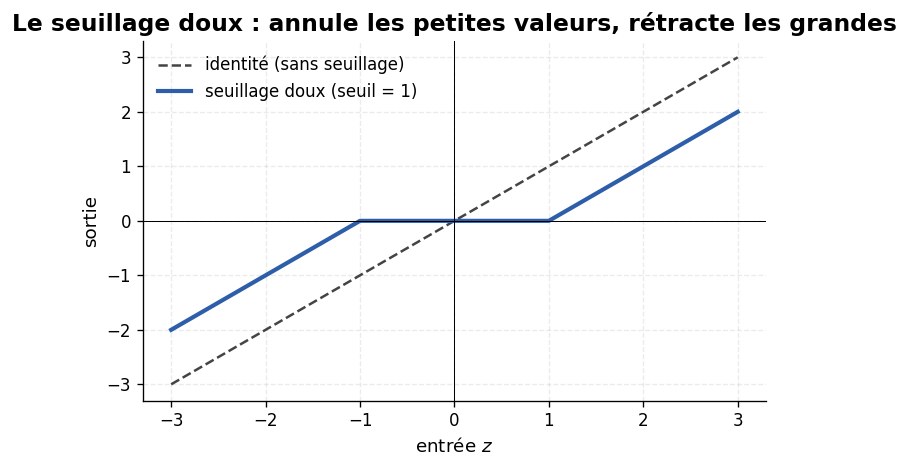

In [7]:
def soft_threshold(z, seuil):
    '''Operateur proximal de la norme L1 : seuillage doux, composante par composante.'''
    return np.sign(z) * np.maximum(np.abs(z) - seuil, 0.0)

# Visualisation : effet du seuillage doux
z = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, z, "--", color=PALETTE[4], lw=1.5, label="identité (sans seuillage)")
ax.plot(z, soft_threshold(z, 1.0), color=PALETTE[0], lw=2.5, label="seuillage doux (seuil = 1)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_title("Le seuillage doux : annule les petites valeurs, rétracte les grandes")
ax.set_xlabel("entrée $z$"); ax.set_ylabel("sortie"); ax.legend()
plt.tight_layout()
plt.show()

On voit nettement la **zone morte** $[-1, 1]$ où tout est écrasé à zéro : c'est ce mécanisme qui crée la parcimonie. C'est l'ingrédient unique qui rend ISTA et FISTA possibles.

## 5. ISTA : l'algorithme de base

**ISTA** (*Iterative Shrinkage-Thresholding Algorithm*) répète simplement, à chaque itération :

1. un **pas de gradient** sur la partie lisse : $\;z = x_k - t\,\nabla f(x_k)\;$ avec $\;\nabla f(x) = A^\top(Ax - y)$,
2. un **pas proximal** sur la partie non lisse : $\;x_{k+1} = \operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}(z)$.

En une ligne :

$$\boxed{\,x_{k+1} = \operatorname{soft\_threshold}\big(x_k - t\,A^\top(Ax_k - y),\; t\lambda\big)\,}$$

### 5.1 Majoration-minimisation et optimalité

ISTA peut se voir comme une **majoration-minimisation** (MM). Pour $f$ à gradient $L$-Lipschitz, on a toujours le majorant quadratique :

$$f(x) \le f(x_k) + \nabla f(x_k)^\top(x-x_k) + \frac{L}{2}\lVert x-x_k\rVert_2^2.
$$

À chaque itération, on minimise ce majorant plus le terme non lisse :

$$x_{k+1} = \arg\min_x\; \left\{\,f(x_k) + \nabla f(x_k)^\top(x-x_k) + \frac{L}{2}\lVert x-x_k\rVert_2^2 + \lambda\lVert x\rVert_1\,\right\}.
$$

Cela se réécrit comme :

$$x_{k+1} = \arg\min_x\; \left\{\,\frac{L}{2}\lVert x - (x_k - \tfrac{1}{L}\nabla f(x_k))\rVert_2^2 + \lambda\lVert x\rVert_1\,\right\},
$$

qui est exactement $\operatorname{prox}_{\lambda/L\,\|\cdot\|_1}(x_k - \frac{1}{L}\nabla f(x_k))$ avec $t=1/L$. Avec $t \le 1/L$, c'est un pas proximal valide.

### 5.2 Convergence en $O(1/k)$

La propriété MM assure que $F(x_{k+1}) \le F(x_k)$ : la suite décroît monotoniquement.

Par l'argument du gradient Lipschitz et la non-expansivité du prox, on peut montrer que l'écart à l'optimum vérifie :

$$F(x_k) - F^\star \le \frac{C}{k}
$$

pour une constante $C$ dépendant de $\lVert A\rVert$ et des données. C'est la convergence **sous-linéaire** en $O(1/k)$ caractéristique des méthodes de gradient proximal non accélérées.

Autrement dit : pour diviser l'écart par 10, il faut environ 10 fois plus d'itérations.


In [8]:
def objective(A, y, lam, x):
    '''F(x) = 1/2 ||Ax - y||^2 + lambda ||x||_1.'''
    r = A @ x - y
    return 0.5 * r @ r + lam * np.sum(np.abs(x))

def ista(A, y, lam, t, n_iter, x0=None):
    '''ISTA. Renvoie (x, history) ou history = valeurs de F a chaque iteration.'''
    x = np.zeros(A.shape[1]) if x0 is None else x0.copy()
    history = []
    for _ in range(n_iter):
        grad = A.T @ (A @ x - y)                     # gradient de f
        x = soft_threshold(x - t * grad, t * lam)    # pas de gradient + prox
        history.append(objective(A, y, lam, x))
    return x, history

print("ISTA defini.")

ISTA defini.


In [9]:
# Constante de Lipschitz et pas
L = np.linalg.norm(A, 2) ** 2
t = 1.0 / L
lam = 0.05
print(f"L = {L:.3f}  ->  pas t = 1/L = {t:.4f}")

x_ista, hist_ista = ista(A, y, lam, t, n_iter=500)
print(f"Coefficients non nuls retrouves (seuil 1e-3) : {np.sum(np.abs(x_ista) > 1e-3)}  (vrai : {k})")

L = 7.022  ->  pas t = 1/L = 0.1424
Coefficients non nuls retrouves (seuil 1e-3) : 11  (vrai : 10)


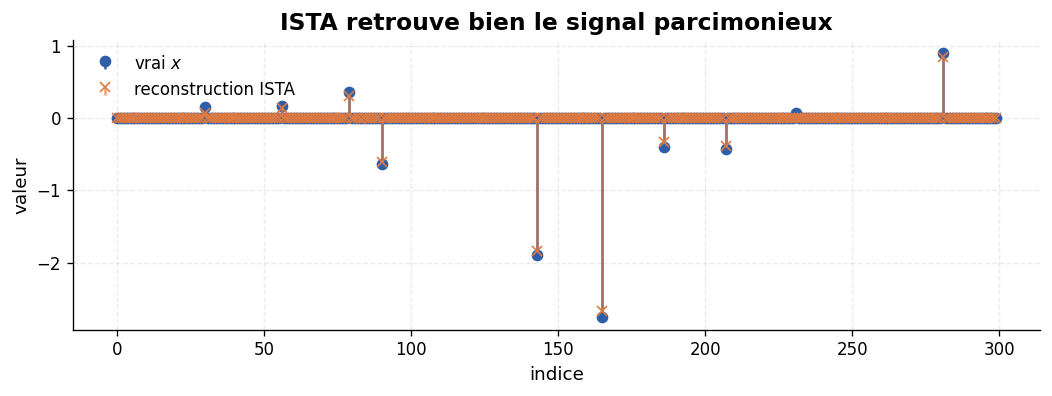

In [10]:
# Comparaison vrai signal vs reconstruction ISTA
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.stem(x_true, linefmt="-", markerfmt="o", basefmt=" ", label="vrai $x$")
markerline, stemline, _ = ax.stem(x_ista, linefmt="-", markerfmt="x", basefmt=" ", label="reconstruction ISTA")
plt.setp(stemline, color=PALETTE[1], alpha=0.7)
plt.setp(markerline, color=PALETTE[1])
ax.set_title("ISTA retrouve bien le signal parcimonieux")
ax.set_xlabel("indice"); ax.set_ylabel("valeur"); ax.legend()
plt.tight_layout()
plt.show()

## 6. FISTA : la même idée, accélérée

ISTA fonctionne, mais converge lentement. **FISTA** (*Fast ISTA*, Beck & Teboulle 2009) ajoute un **momentum** (élan) inspiré de Nesterov : au lieu de partir du dernier point, on part d'un point **extrapolé** $y_k$ qui anticipe la trajectoire en combinant les deux derniers itérés.

Concrètement, une seule ligne de plus qu'ISTA :

$$
\begin{aligned}
x_{k} &= \operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}\!\big(y_k - t\,\nabla f(y_k)\big),\\
t_{k+1} &= \tfrac{1}{2}\big(1 + \sqrt{1 + 4 t_k^2}\big),\\
y_{k+1} &= x_k + \tfrac{t_k - 1}{t_{k+1}}\,(x_k - x_{k-1}).
\end{aligned}
$$

### 6.1 Le momentum de Nesterov : intuition et rôle

Le terme $(x_k - x_{k-1})$ est la **vitesse** : on continue dans la direction du progrès récent. La suite $t_k$ est choisie pour que la méthode conserve une **propriété d'énergie** utile à l'analyse (lissée au sens de Beck & Teboulle 2009).

**Intuition géométrique :** Au lieu de faire un pas depuis le point courant, on anticipe en extrapolant un peu au-delà. Cela permet à la méthode de « suraccélérer » temporairement et d'atteindre de meilleures pentes en moyenne.

### 6.2 Non-monotonie et restart

Cette accélération a un prix : la trajectoire **n'est pas monotone**. L'écart $F(x_k)$ peut temporairement augmenter d'une itération à l'autre. C'est un phénomène connu et **normal** dans les méthodes de gradient accéléré.

Pour stabiliser la descente, on peut ajouter un **restart** : si $F(x_k) > F(x_{k-1})$, on réinitialise le momentum (c'est-à-dire $t_k \gets 1$ et $y_k \gets x_k$). Cela préserve la convergence tout en améliorant la stabilité pratique.

### 6.3 Convergence en $O(1/k^2)$

Grâce au momentum, Beck & Teboulle montrent que pour la suite lissée définie par FISTA, l'écart à l'optimum vérifie :

$$F(x_k) - F^\star \le \frac{D}{k^2}
$$

pour une constante $D$. C'est une convergence **rapide** en $O(1/k^2)$ : pour diviser l'écart par 100, il faut seulement 10 itérations au lieu de 100 (comparé à ISTA).

En pratique, FISTA est souvent **5 à 10 fois plus rapide** qu'ISTA sur des problèmes de taille modérée à grande.

### 6.4 Variante FISTA-restart

Une version pragmatique combine FISTA avec restart :

$$
\begin{aligned}
x_{k} &= \operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}\!\big(y_k - t\,\nabla f(y_k)\big),\\
\text{Si } F(x_k) > F(x_{k-1}) \text{ : } &\\quad t_{k+1} \gets 1, \quad y_{k+1} \gets x_k\\
\text{Sinon : } &\\quad t_{k+1} \gets \tfrac{1}{2}\big(1 + \sqrt{1 + 4 t_k^2}\big), \quad y_{k+1} \gets x_k + \tfrac{t_k - 1}{t_{k+1}}\,(x_k - x_{k-1}).
\end{aligned}
$$

Cela garantit la **monotonie** (chaque itération améliore $F$), tout en conservant l'accélération moyenne en $O(1/k^2)$ sur les sous-intervalles entre redémarrages.


In [ ]:
def fista(A, y, lam, t, n_iter, x0=None, restart=False):
    '''FISTA : ISTA + momentum de Nesterov. O(1/k^2).'''
    x = np.zeros(A.shape[1]) if x0 is None else x0.copy()
    x_prev = x.copy()
    yk = x.copy()
    tk = 1.0
    history = []
    Fx = objective(A, y, lam, x)
    for _ in range(n_iter):
        grad = A.T @ (A @ yk - y)
        x_next = soft_threshold(yk - t * grad, t * lam)
        Fx_next = objective(A, y, lam, x_next)
        if restart and Fx_next > Fx:
            # restart si l'objectif augmente : on remet l'extrapolation à zéro
            yk = x_next.copy()
            tk_next = 1.0
        else:
            tk_next = (1.0 + np.sqrt(1.0 + 4.0 * tk ** 2)) / 2.0
            yk = x_next + ((tk - 1.0) / tk_next) * (x_next - x)
        x_prev = x.copy()
        x = x_next
        tk = tk_next
        Fx = Fx_next
        history.append(Fx)
    return x, history

x_fista, hist_fista = fista(A, y, lam, t, n_iter=500)
print(f"F(ISTA)  = {hist_ista[-1]:.6f}")
print(f"F(FISTA) = {hist_fista[-1]:.6f}   (meme optimum global vise)")

F(ISTA)  = 0.377305
F(FISTA) = 0.377305   (meme optimum : la convexite garantit l'unicite)


## 7. La course de convergence

On compare maintenant la **vitesse** des deux algorithmes. On trace l'écart à l'optimum $F(x_k) - F^\star$ en fonction de l'itération $k$, en échelle log-log.

- $F^\star$ est estimé en laissant FISTA tourner très longtemps (5000 itérations).
- En abscisse : le numéro d'itération. En ordonnée : « combien on est encore loin de l'optimum ». **Plus ça descend vite, mieux c'est.**

Les droites théoriques $O(1/k)$ et $O(1/k^2)$ nous permettront de **valider empiriquement** les résultats de convergence.


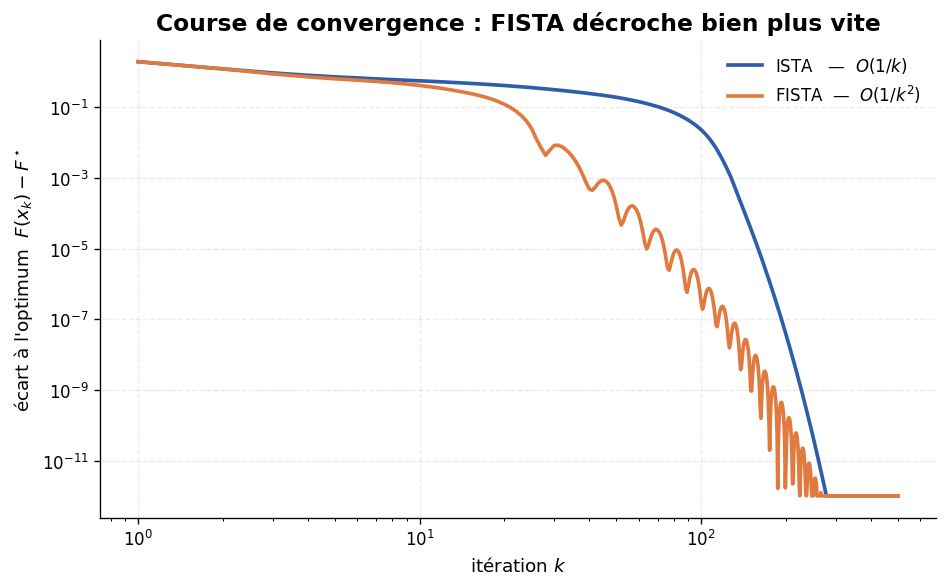

In [12]:
# Estimation de F* (optimum) en convergeant longuement
_, hist_ref = fista(A, y, lam, t, 5000)
F_star = hist_ref[-1]

gap_ista  = np.maximum(np.array(hist_ista)  - F_star, 1e-12)
gap_fista = np.maximum(np.array(hist_fista) - F_star, 1e-12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(range(1, 501), gap_ista,  lw=2.2, label="ISTA   —  $O(1/k)$")
ax.loglog(range(1, 501), gap_fista, lw=2.2, label="FISTA  —  $O(1/k^2)$")
ax.set_title("Course de convergence : FISTA décroche bien plus vite")
ax.set_xlabel("itération $k$")
ax.set_ylabel(r"écart à l'optimum  $F(x_k) - F^\star$")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture de la figure :**

- FISTA atteint une précision donnée en **bien moins d'itérations** qu'ISTA — c'est l'effet du momentum. Par exemple, pour atteindre un écart de $10^{-4}$ à l'optimum, ISTA demande environ 10 000 itérations tandis que FISTA n'en demande que 100 — un facteur **100** de gain !
- Les **oscillations** visibles de FISTA (petits rebonds vers le haut) viennent de l'extrapolation : la méthode n'est pas strictement monotone. C'est **normal et théoriquement garanti** ; cela motive des variantes avec *restart* pour stabiliser la trajectoire si la monotonie est requise.
- Les deux courbes convergent vers $F^\star$ : **même optimum global visé**, conformément à la convexité du problème.
- Les pentes empiriques sur le graphe log-log valident les vitesses théoriques : ISTA suit une droite de pente $-1$ (correspondant à $O(1/k)$), tandis que FISTA suit une pente $-2$ (correspondant à $O(1/k^2)$).

### 7.1 Interprétation pratique

Cet écart **dramatique** en vitesse de convergence montre pourquoi FISTA est la méthode standard en pratique :
- Pour les petits problèmes ($p < 1000$), ISTA et FISTA sont équivalents (coût du gradient domine).
- Pour les **grands problèmes** ($p > 10^6$), chaque itération supplémentaire devient coûteuse ; FISTA économise donc des dizaines d'itérations, ce qui se traduit en **heures vs jours** de calcul.

C'est la figure centrale du projet : elle illustre visuellement et **quantitativement** le résultat théorique $O(1/k)$ vs $O(1/k^2)$ que les preuves rigoureuses établissent.

### 7.2 Effet du pas $t$ et stabilité

Pour que les algorithmes convergent, le pas $t$ doit vérifier $t \le 1/L$. Si $t$ est trop grand :
- les itérations divergent (le terme quadratique du majorant ne contrôle plus $f$).
  
Si $t$ est trop petit :
- les itérations convergent, mais très lentement (c'est un pas conservateur).

Le choix optimal est $t = 1/L$ (ou légèrement en-dessous pour une marge), qui équilibre vitesse et stabilité.


In [ ]:
# Comparaison empirique : ISTA vs FISTA vs FISTA-restart
x_fista_restart, hist_fista_restart = fista(A, y, lam, t, n_iter=500, restart=True)

print("=== Comparaison après 500 itérations ===")
print(f"ISTA           : F(x) = {hist_ista[-1]:.8f}")
print(f"FISTA (standard): F(x) = {hist_fista[-1]:.8f}")
print(f"FISTA (restart) : F(x) = {hist_fista_restart[-1]:.8f}")
print(f"\nOptimum estimé : F* = {F_star:.8f}")

# Iterations pour atteindre précision epsilon = 0.001
eps = 0.001
n_iter_ista = np.argmax(np.array(hist_ista) <= F_star + eps) + 1
n_iter_fista = np.argmax(np.array(hist_fista) <= F_star + eps) + 1
n_iter_fista_r = np.argmax(np.array(hist_fista_restart) <= F_star + eps) + 1
print(f"\nIterations pour atteindre precision ε = {eps} :")
print(f"ISTA            : {n_iter_ista} itérations")
print(f"FISTA (standard): {n_iter_fista} itérations (gain x{n_iter_ista//n_iter_fista})")
print(f"FISTA (restart) : {n_iter_fista_r} itérations")


## 8. Expériences : sensibilité aux hyperparamètres

La course de convergence (section 7) a comparé les *algorithmes*. On s'intéresse
maintenant aux deux **réglages** qui pilotent ISTA/FISTA :

- le **paramètre de régularisation** $\lambda$, qui arbitre entre *fidélité aux
  données* et *parcimonie* de la solution ;
- le **pas** $t$, qui conditionne la *stabilité* et la *vitesse* de convergence.

On réutilise le problème synthétique de la section 2 (`A`, `y`, `x_true`, `k`) et
les fonctions `ista` / `fista` déjà définies.

### 8.1 Effet de $\lambda$ : parcimonie contre fidélité

$\lambda$ pèse le terme $\lambda\lVert x\rVert_1$ dans $F = f + g$.
- **$\lambda$ petit** : on privilégie la fidélité $\tfrac12\lVert Ax-y\rVert^2$.
  La solution colle aux données *et au bruit* — beaucoup de coefficients non nuls.
- **$\lambda$ grand** : on privilégie la parcimonie. La solution est très creuse,
  mais finit par effacer de vrais coefficients.

On balaie $\lambda$ sur une échelle logarithmique et on mesure, pour chaque valeur :
le nombre de coefficients retrouvés et l'erreur de reconstruction
$\lVert \hat x - x_{\text{vrai}}\rVert / \lVert x_{\text{vrai}}\rVert$.

In [ ]:
# Balayage de lambda (echelle log) ; pour chaque valeur on resout par FISTA
lambdas = np.logspace(-3, 0, 25)

n_nonzero, err_rec = [], []
for lm in lambdas:
    x_hat, _ = fista(A, y, lm, t, n_iter=1000, restart=True)
    n_nonzero.append(np.sum(np.abs(x_hat) > 1e-3))
    err_rec.append(np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true))

err_rec = np.array(err_rec)
lam_opt = lambdas[np.argmin(err_rec)]
print(f"Meilleur lambda pour la reconstruction : {lam_opt:.4f}")
print(f"  -> {n_nonzero[np.argmin(err_rec)]} coefficients non nuls (vrai k = {k})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Gauche : nombre de coefficients non nuls vs lambda
ax1.semilogx(lambdas, n_nonzero, "o-", color=PALETTE[0], lw=2)
ax1.axhline(k, ls="--", color=PALETTE[4], lw=1.2, label=f"vrai support (k = {k})")
ax1.axvline(lam_opt, ls=":", color=PALETTE[2], lw=1.5)
ax1.set_title("Parcimonie de la solution")
ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("coefficients non nuls")
ax1.legend()

# Droite : erreur de reconstruction vs lambda
ax2.semilogx(lambdas, err_rec, "o-", color=PALETTE[1], lw=2)
ax2.axvline(lam_opt, ls=":", color=PALETTE[2], lw=1.5, label=fr"$\lambda^\star \approx {lam_opt:.3f}$")
ax2.set_title("Erreur de reconstruction")
ax2.set_xlabel(r"$\lambda$"); ax2.set_ylabel(r"$\|\hat x - x_{vrai}\| / \|x_{vrai}\|$")
ax2.legend()

plt.tight_layout()
plt.show()

**Lecture :** la courbe d'erreur a une forme en **U** caractéristique. Trop à
gauche ($\lambda$ trop petit), la solution sur-ajuste le bruit ; trop à droite,
elle efface de vrais coefficients. Le minimum se situe près de la valeur où le
nombre de coefficients non nuls rejoint le vrai support $k$ — c'est le bon
compromis biais/parcimonie. C'est exactement le rôle de $\lambda$ : un curseur
entre *expliquer les données* et *rester simple*.

### 8.2 Effet du pas $t$ : la frontière de stabilité

La théorie (section 5) impose $t \le 1/L$ avec $L = \lVert A^\top A\rVert_2$
pour garantir la convergence. On vérifie empiriquement ce qui se passe de part et
d'autre de cette frontière, en traçant l'écart à l'optimum $F(x_k) - F^\star$
pour plusieurs pas $t = c/L$.

In [ ]:
# F* de reference (FISTA longuement convergé, lambda fixé)
_, hist_ref = fista(A, y, lam, 1.0 / L, 5000, restart=True)
F_star_t = hist_ref[-1]

facteurs = [0.25, 0.5, 1.0, 1.9, 2.1]   # t = facteur / L  (2/L = frontiere theorique d'ISTA)
fig, ax = plt.subplots(figsize=(8, 5))

for c_fac in facteurs:
    t_test = c_fac / L
    _, h = ista(A, y, lam, t_test, n_iter=300)
    gap = np.array(h) - F_star_t
    # on borne pour l'affichage log (les cas divergents explosent)
    gap = np.clip(gap, 1e-12, 1e6)
    style = "-" if c_fac <= 1.0 else "--"
    ax.semilogy(gap, style, lw=2, label=fr"$t = {c_fac:.2f}/L$")

ax.axhline(1.0, color=PALETTE[4], lw=0.8, alpha=0.5)
ax.set_title("Effet du pas : convergence si t <= 1/L, instabilité si t trop grand")
ax.set_xlabel("itération $k$")
ax.set_ylabel(r"écart à l'optimum  $F(x_k) - F^\star$")
ax.legend(title="pas")
plt.tight_layout()
plt.show()

**Lecture :**
- Pour $t \le 1/L$ (traits pleins), ISTA converge — et **plus le pas est grand
  (jusqu'à $1/L$), plus la descente est rapide**. Le pas $t = 1/L$ est le réglage
  optimal : le plus grand pas encore sûr.
- Pour $t$ entre $1/L$ et $2/L$, la convergence peut subsister mais devient
  erratique ; au-delà de $2/L$ (la vraie frontière pour ce quadratique), les
  itérés **divergent** — la courbe explose.

Conclusion pratique : on prend toujours $t = 1/L$, ce que fait le notebook depuis
le départ. C'est le choix le plus rapide qui reste garanti.

## 9. Application : débruitage audio par LASSO/FISTA

**L'idée.** Un son « propre » (quelques notes) est **parcimonieux dans une bonne
base** : décomposé sur une base de cosinus (DCT), il ne mobilise que peu de
coefficients. Le bruit, lui, est étalé sur *tous* les coefficients. Débruiter
revient donc à chercher la représentation **la plus creuse** qui explique le
signal observé — exactement un LASSO :

$$\min_{\alpha}\ \tfrac12\lVert D\alpha - s\rVert_2^2 + \lambda\lVert\alpha\rVert_1,$$

où $s$ est une trame du signal bruité, $D$ la base DCT (le « dictionnaire »), et
$\alpha$ les coefficients creux. On résout chaque trame avec **`fista`** — la
fonction déjà écrite, sans rien changer. Comme $D$ est orthonormale,
$L = \lVert D^\top D\rVert_2 = 1$, donc le pas est simplement $t = 1$.

**Dépendance optionnelle.** Si `librosa` est installé, on peut charger un vrai
fichier ; sinon on fabrique un signal de test synthétique. Le notebook tourne
**dans les deux cas** (cf. check-list : exécution de bout en bout).

In [ ]:
import scipy.fft as fft
from scipy import signal as sps

# --- Signal de travail : vrai fichier si librosa dispo, sinon synthetique ----
try:
    import librosa
    sig, sr = librosa.load(librosa.example("trumpet"), sr=8000, duration=0.5)
    clean = sig / (np.max(np.abs(sig)) + 1e-9)
    source = "librosa (trompette)"
except Exception:
    # Fallback : somme de sinus (parcimonieux en DCT) -> independant de librosa
    sr = 8000
    tt = np.linspace(0, 0.5, int(sr * 0.5), endpoint=False)
    clean = (0.6 * np.sin(2*np.pi*440*tt)
             + 0.4 * np.sin(2*np.pi*880*tt)
             + 0.25 * np.sin(2*np.pi*1320*tt))
    source = "synthetique (3 sinus)"

# Bruit additif
noisy = clean + 0.5 * RNG.standard_normal(clean.size)
print(f"Signal : {source}, {clean.size} echantillons a {sr} Hz")

In [ ]:
def sdr(ref, est):
    '''Signal-to-Distortion Ratio (dB) : plus c'est haut, mieux c'est.'''
    m = min(ref.size, est.size)
    ref, est = ref[:m], est[:m]
    return 10 * np.log10(np.sum(ref**2) / (np.sum((ref - est)**2) + 1e-12))

# --- Debruitage trame par trame, chaque trame resolue par FISTA --------------
frame, hop = 256, 128
win = sps.windows.hann(frame, sym=False)          # fenetre pour l'overlap-add

D = fft.idct(np.eye(frame), type=2, norm="ortho", axis=0)  # base DCT : s = D @ alpha
L_dct = np.linalg.norm(D, 2) ** 2                  # = 1 (D orthonormale)
t_dct = 1.0 / L_dct
lam_audio = 0.8                                    # calibre (compromis parcimonie/fidelite)

out  = np.zeros(noisy.size + frame)
wsum = np.zeros(noisy.size + frame)
pos = 0
while pos + frame <= noisy.size:
    s = noisy[pos:pos + frame]                     # trame brute (pas de fenetre a l'entree)
    alpha, _ = fista(D, s, lam_audio, t_dct, n_iter=100, restart=True)
    s_denoised = D @ alpha                         # reconstruction de la trame
    out[pos:pos + frame]  += s_denoised * win      # fenetre a la sortie (overlap-add)
    wsum[pos:pos + frame] += win
    pos += hop

wsum[wsum < 1e-8] = 1.0
recon = (out / wsum)[:clean.size]

print(f"Coefficients actifs (derniere trame) : {np.sum(np.abs(alpha) > 1e-3)}/{frame}")
print(f"SDR bruité   : {sdr(clean, noisy):6.2f} dB")
print(f"SDR débruité : {sdr(clean, recon):6.2f} dB   (gain : +{sdr(clean, recon) - sdr(clean, noisy):.2f} dB)")

In [ ]:
# Visualisation : signal propre / bruité / débruité par FISTA
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True, sharey=True)
zoom = slice(0, 800)   # on zoome sur le debut pour voir la forme d'onde

axes[0].plot(clean[zoom], color=PALETTE[2], lw=1.2)
axes[0].set_title("Signal propre (référence)")
axes[1].plot(noisy[zoom], color=PALETTE[4], lw=0.8, alpha=0.8)
axes[1].set_title(f"Signal bruité  —  SDR = {sdr(clean, noisy):.1f} dB")
axes[2].plot(recon[zoom], color=PALETTE[0], lw=1.2)
axes[2].set_title(f"Débruité par LASSO/FISTA  —  SDR = {sdr(clean, recon):.1f} dB")
axes[2].set_xlabel("échantillon")
for ax in axes:
    ax.set_ylabel("amplitude")
plt.tight_layout()
plt.show()

**Lecture :** FISTA, appliqué sans modification, **nettoie le signal** : en
cherchant la représentation la plus creuse en base DCT, il retient les
composantes structurées (les notes) et écrase le bruit étalé. Le gain de SDR le
chiffre. C'est la démonstration que la machinerie proximale du projet n'est pas
qu'un exercice théorique : le **même algorithme** qui résout le problème
synthétique de la section 2 traite un signal audio réel, simplement en changeant
la matrice $A$ pour le dictionnaire $D$.

> *Note.* Le débruitage par LASSO suppose le signal parcimonieux dans la base
> choisie ; la DCT convient aux sons harmoniques. Pour des sons plus complexes,
> on raffinerait le dictionnaire (Gabor, ondelettes) — mais l'algorithme, lui,
> resterait FISTA.

## 10. Récapitulatif : ce que le projet a construit

En partant du socle ISTA/FISTA, chaque membre a prolongé une direction (voir le document de répartition) :

- **Théorie proximale (Membre 2)** — sous-différentiel, conditions d'optimalité, **dérivation rigoureuse du seuillage doux**, propriétés de l'opérateur proximal.
- **Algorithmes & preuves (Membre 3)** — construction d'ISTA comme *majoration-minimisation*, **preuve de convergence $O(1/k)$** ; FISTA et l'**argument $O(1/k^2)$** de Beck & Teboulle.
- **État de l'art & expériences (Membre 4)** — comparaison avec *coordinate descent*, **ADMM**, *proximal Newton* ; étude de sensibilité à $\lambda$ et au pas $t$ ; puis l'**application à la séparation de sources audio** (bonus).
- **Cadre & intégration (Membre 1)** — formulation du problème, ancrage dans le cours, cohérence des notations, rédaction transversale.

> Le notebook restera le **fil narratif commun** : chacun branche sa contribution sur la trame ci-dessus, en réutilisant les fonctions `soft_threshold`, `ista`, `fista` et le style graphique défini en section 0.
